**Practical 1A  Feature engineering on Categorical and Numerical data**

In [ ]:
import numpy as np
import pandas as pd

titanic=pd.read_csv("/content/titanic - titanic.csv")
titanic.head

<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch            Ticket     Fare Cabin Embarked  
0        0         A/5 21171   7.2500   NaN        S  
1        0          PC 17599  71.2833   C85        C  
2        0  STON/O2. 3101282   7.9250   NaN        S  
3        0            113803  53.1000  C123        S  
4        0            373450   8.0500   NaN        S  
..     ...               ...      ...   ...      ...  
886      0            211536  13.0000   NaN        S  
887      0            112053  30.0000   B42        S  
888      2        W./C. 6607  23.4500   NaN        S  
889      0            111369  30.0000  C148        C  
890      0            370376   7.7500   NaN        Q  

[891 rows x 12 columns]>

In [ ]:
data1=titanic.copy()
data1.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
data1.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
print('total passengers with values in all variables: ',data1.dropna().shape[0])
print('total passengers in the titanic: ',data1.shape[0])
print('total passengers with missing values: ',data1.dropna().shape[0]/ np.float64(data1.shape[0]))


total passengers with values in all variables:  183
total passengers in the titanic:  891
total passengers with missing values:  0.2053872053872054


In [ ]:
data1['Age_NA']=np.where(data1['Age'].isnull(),1,0)
data1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_NA
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [ ]:
print(data1.Age.mean())
(data1.Age.median())

29.69911764705882


28.0

In [ ]:
data1['Age'] = data1['Age'].fillna(data1['Age'].median())

In [ ]:
corr = data1.corr(numeric_only=True)
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_NA
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.020167
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,-0.092197
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.172933
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.052098
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.018958
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,-0.124104
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,-0.100707
Age_NA,-0.020167,-0.092197,0.172933,-0.052098,0.018958,-0.124104,-0.100707,1.000000


In [ ]:
cor=data1[['Age','Fare']].corr()
cor

,Age,Fare
Age,1.000000,0.096688
Fare,0.096688,1.000000


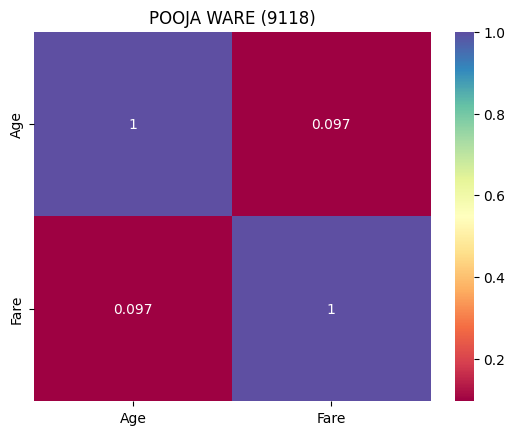

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cor, cmap='Spectral', annot=True)
plt.title('POOJA WARE (9118)')
plt.show()


In [ ]:
cor=data1[['Fare','Pclass']].corr()
cor

,Fare,Pclass
Fare,1.0000,-0.5495
Pclass,-0.5495,1.0000


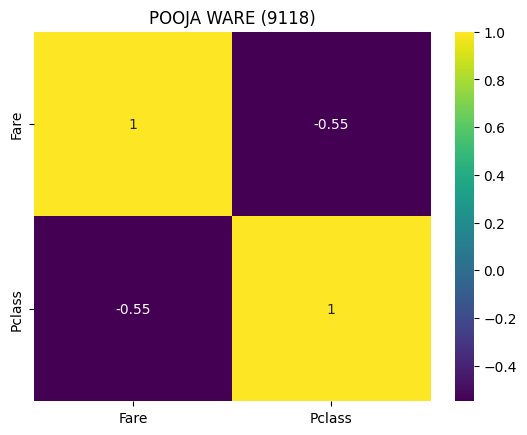

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Plot heatmap
sns.heatmap(cor, cmap='viridis', annot=True)
plt.title('POOJA WARE (9118)')
plt.show()

In [ ]:
pd.get_dummies(data1['Sex']).head()

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [ ]:
pd.concat([data1['Sex'],pd.get_dummies(data1['Sex'])],axis=1).head()

,Sex,female,male
0,male,False,True
1,female,True,False
2,female,True,False
3,female,True,False
4,male,False,True


# **Practical 1B Feature Engineering on Data time feature**

In [ ]:

import pandas as pd
import numpy as np
path ="/content/loan - loan.csv"
df=pd.read_csv(path)
df.head()

,customer_id,disbursed_amount,interest,market,employment,time_employed,householder,income,date_issued,target,loan_purpose,number_open_accounts,date_last_payment,number_credit_lines_12
0,0,23201.5,15.4840,C,Teacher,<=5 years,RENT,84600.0,2013-06-11,0,Debt consolidation,4,2016-01-14,NaN
1,1,7425.0,11.2032,B,Accountant,<=5 years,OWNER,102000.0,2014-05-08,0,Car purchase,13,2016-01-25,NaN
2,2,11150.0,8.5100,A,Statistician,<=5 years,RENT,69840.0,2013-10-26,0,Debt consolidation,8,2014-09-26,NaN
3,3,7600.0,5.8656,A,Other,<=5 years,RENT,100386.0,2015-08-20,0,Debt consolidation,20,2016-01-26,NaN
4,4,31960.0,18.7392,E,Bus driver,>5 years,RENT,95040.0,2014-07-22,0,Debt consolidation,14,2016-01-11,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  int64  
 1   disbursed_amount        10000 non-null  float64
 2   interest                10000 non-null  float64
 3   market                  10000 non-null  object 
 4   employment              9389 non-null   object 
 5   time_employed           9471 non-null   object 
 6   householder             10000 non-null  object 
 7   income                  10000 non-null  float64
 8   date_issued             10000 non-null  object 
 9   target                  10000 non-null  int64  
 10  loan_purpose            10000 non-null  object 
 11  number_open_accounts    10000 non-null  int64  
 12  date_last_payment       10000 non-null  object 
 13  number_credit_lines_12  238 non-null    float64
dtypes: float64(4), int64(3), object(7)
memo

In [ ]:
df['Date'] = pd.to_datetime(df['date_issued'])
df['Month'] = df['Date'].dt.month
df['date_issued:year'] = df['Date'].dt.year
df['day'] = df ['Date'].dt.day

In [ ]:
df[['day', 'Month', 'date_issued:year']]

,day,Month,date_issued:year
0,11,6,2013
1,8,5,2014
2,26,10,2013
3,20,8,2015
4,22,7,2014
...,...,...,...
9995,14,1,2010
9996,20,3,2015
9997,3,4,2015
9998,23,11,2014


In [ ]:
df['date_issued:month'] = df['Date'].dt.month
df['date_issued:day'] = df['Date'].dt.day
df['date_issued:day_of_week'] = df['Date'].dt.day_of_week
df['date_issued:day_of_year'] = df['Date'].dt.dayofyear


In [ ]:
df[['date_issued', 'date_issued:year', 'date_issued:month',
    'date_issued:day', 'date_issued:day_of_week',
    'date_issued:day_of_year']].head()

,date_issued,date_issued:year,date_issued:month,date_issued:day,date_issued:day_of_week,date_issued:day_of_year
0,2013-06-11,2013,6,11,1,162
1,2014-05-08,2014,5,8,3,128
2,2013-10-26,2013,10,26,5,299
3,2015-08-20,2015,8,20,3,232
4,2014-07-22,2014,7,22,1,203


In [ ]:

def week_part(day):
    if day in [1, 2, 3, 4, 5, 6, 7]:
        return "Week 1"
    elif day in [8, 9, 10, 11, 12, 13, 14]:
        return "Week 2"
    elif day in [15, 16, 17, 18, 19, 20, 21]:
        return "Week 3"
    elif day in [22, 23, 24, 25, 26, 27, 28]:
        return "Week 4"
    elif day in [29, 30, 31]:
        return "Week 5"

In [ ]:
df['date_issued:hour'] = df['Date'].dt.hour
df['date_issued:Week_No'] = df['date_issued:day'].apply(week_part)
df[['date_issued:day', 'date_issued:Week_No']].head()


,date_issued:day,date_issued:Week_No
0,11,Week 2
1,8,Week 2
2,26,Week 4
3,20,Week 3
4,22,Week 4


# **Practical 1C Feature Transformation**

In [ ]:
import pandas as pd
import numpy as np
url ='/content/Sample - Superstore - Sample - Superstore.csv'
df_orders=pd.read_csv(url,encoding='latin1')
df_orders.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df_orders.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df_orders.info

<bound method DataFrame.info of             Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0     CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
1     CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
2     CA-2016-138688  06-12-2016   6/16/2016    Second Class    DV-13045   
3     US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   
4     US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   
...              ...         ...         ...             ...         ...   
9989  CA-2014-110422   1/21/2014   1/23/2014    Second Class    TB-21400   
9990  CA-2017-121258   2/26/2017  03-03-2017  Standard Class    DB-13060   
9991  CA-2017-121258   2/26/2017  03-03-2017  Standard Class    DB-13060   
9992  CA-2017-121258   2/26/2017  03-03-2017  Standard Class    DB-13060   
9993  CA-2017-119914  05-04-2017  05-09-2017    Second Class    CC-12220   

         Customer Name    Segment        Country             City       State  \
0          Claire Gute   Consumer  United States        Henderson    Kentucky   
1          Claire Gute   Consumer  United States        Henderson    Kentucky   
2      Darrin Van Huff  Corporate  United States      Los Angeles  California   
3       Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4       Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
...                ...        ...            ...              ...         ...   
9989  Tom Boeckenhauer   Consumer  United States            Miami     Florida   
9990       Dave Brooks   Consumer  United States       Costa Mesa  California   
9991       Dave Brooks   Consumer  United States       Costa Mesa  California   
9992       Dave Brooks   Consumer  United States       Costa Mesa  California   
9993      Chris Cortes   Consumer  United States      Westminster  California   

      ...     Sales Quantity Discount    Profit Sales_log Sales_log2  \
0     ...  261.9600        2     0.00   41.9136  5.568192   8.033203   
1     ...  731.9400        3     0.00  219.5820  6.595699   9.515582   
2     ...   14.6200        2     0.00    6.8714  2.682390   3.869871   
3     ...  957.5775        5     0.45 -383.0310  6.864407   9.903245   
4     ...   22.3680        2     0.20    2.5164  3.107631   4.483364   
...   ...       ...      ...      ...       ...       ...        ...   
9989  ...   25.2480        3     0.20    4.1028  3.228747   4.658097   
9990  ...   91.9600        2     0.00   15.6332  4.521354   6.522935   
9991  ...  258.5760        2     0.20   19.3932  5.555190   8.014445   
9992  ...   29.6000        4     0.00   13.3200  3.387774   4.887525   
9993  ...  243.1600        2     0.00   72.9480  5.493720   7.925762   

      Sales_log10  Sales_rep  Quantity_sq  Sales_sqrt  
0        2.418235   0.003817            4   16.185178  
1        2.864475   0.001366            9   27.054390  
2        1.164947   0.068399            4    3.823611  
3        2.981174   0.001044           25   30.944749  
4        1.349627   0.044707            4    4.729482  
...           ...        ...          ...         ...  
9989     1.402227   0.039607            9    5.024739  
9990     1.963599   0.010874            4    9.589578  
9991     2.412588   0.003867            4   16.080299  
9992     1.471292   0.033784           16    5.440588  
9993     2.385892   0.004113            4   15.593588  

[9994 rows x 26 columns]>

**1.Transformation in type of data**

In [ ]:
df_orders['Profit']=df_orders['Profit'].astype('int64')
df_orders['Segment']=df_orders['Segment'].astype('category')
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Order ID       9994 non-null   object  
 1   Order Date     9994 non-null   object  
 2   Ship Date      9994 non-null   object  
 3   Ship Mode      9994 non-null   object  
 4   Customer ID    9994 non-null   object  
 5   Customer Name  9994 non-null   object  
 6   Segment        9994 non-null   category
 7   Country        9994 non-null   object  
 8   City           9994 non-null   object  
 9   State          9994 non-null   object  
 10  Postal Code    9994 non-null   int64   
 11  Region         9994 non-null   object  
 12  Product ID     9994 non-null   object  
 13  Category       9994 non-null   object  
 14  Sub-Category   9994 non-null   object  
 15  Product Name   9994 non-null   object  
 16  Sales          9994 non-null   float64 
 17  Quantity       9994 non-null   in

**2.Custom Transformation**

In [ ]:
df_orders['UnitPrice']=df_orders['Sales']/df_orders['Quantity']
df_orders[['Sales','Quantity','UnitPrice']].head()

,Sales,Quantity,UnitPrice
0,261.9600,2,130.9800
1,731.9400,3,243.9800
2,14.6200,2,7.3100
3,957.5775,5,191.5155
4,22.3680,2,11.1840


[link text](https://)3.Log **Transformation**

In [ ]:
df_orders['Sales_log']= np.log(df_orders['Sales'])
df_orders[['Sales','Sales_log']].head()


,Sales,Sales_log
0,261.9600,5.568192
1,731.9400,6.595699
2,14.6200,2.682390
3,957.5775,6.864407
4,22.3680,3.107631


In [ ]:
df_orders['Sales_log2']= np.log2(df_orders['Sales'])
df_orders[['Sales','Sales_log2']].head()

,Sales,Sales_log2
0,261.9600,8.033203
1,731.9400,9.515582
2,14.6200,3.869871
3,957.5775,9.903245
4,22.3680,4.483364


In [ ]:
df_orders['Sales_log10']= np.log10(df_orders['Sales'])
df_orders[['Sales','Sales_log10']].head()

,Sales,Sales_log10
0,261.9600,2.418235
1,731.9400,2.864475
2,14.6200,1.164947
3,957.5775,2.981174
4,22.3680,1.349627


4.Reciporcal **Transformation**

In [ ]:
df_orders["Sales_rep"]=np.reciprocal(df_orders["Sales"])
df_orders[['Sales','Sales_rep']].head()

,Sales,Sales_rep
0,261.9600,0.003817
1,731.9400,0.001366
2,14.6200,0.068399
3,957.5775,0.001044
4,22.3680,0.044707


**5.Square Transformation/power Transformation**

In [ ]:
df_orders['Quantity_sq']=np.power(df_orders['Quantity'],2)
df_orders[['Quantity','Quantity_sq']].head()

,Quantity,Quantity_sq
0,2,4
1,3,9
2,2,4
3,5,25
4,2,4


**6.SquareRoot Transformation**

In [ ]:
df_orders['Sales_sqrt']=np.sqrt(df_orders['Sales'])
df_orders[['Sales','Sales_sqrt']].head()

,Sales,Sales_sqrt
0,261.9600,16.185178
1,731.9400,27.054390
2,14.6200,3.823611
3,957.5775,30.944749
4,22.3680,4.729482
